# Explainable Breast-Ultrasound Pipeline on BUS-CoT: CNN &#8594; Grad-CAM &#8594; Caption &#8594; CoT-grounded Evaluation

**image &#8594; CNN classifier &#8594; Grad-CAM &#8594; heatmap &#8594; ROI-conditioned caption &#8594; evaluate against BUS-CoT's own reasoning text**

**What changed from the previous version**
- **Single dataset now: BUS-CoT**, used for *both* halves of the pipeline &mdash; its images + diagnostic labels train the classifier, and its chain-of-thought reasoning text is the ground truth the generated captions get evaluated against. BUSI and ROCOv2 are no longer used here.
- **Dataset inspection comes first**, on purpose. You uploaded this yourself as a private Kaggle Dataset and I don't know its exact internal folder/field layout, so Sections 1&ndash;4 discover and print the real structure before any modeling code assumes field names. **Section 5 is a config cell you need to fill in by hand** based on what Sections 2&ndash;4 print out.
- **Classifier backbone is unchanged**: RadImageNet-pretrained DenseNet-121 (medical-image pretraining instead of ImageNet).
- **New**: an evaluation section that scores generated captions against BUS-CoT's own reasoning text with ROUGE and a simple keyword-overlap check, with the usual caveat that both are surface-overlap metrics, not faithfulness metrics &mdash; noted in the final cell.

**Before running:** *Settings* &#8594; **Internet: On**, **Accelerator: GPU**. Attach your uploaded BUS-CoT dataset via *Add Data*.

In [1]:
# !pip install -q -U huggingface_hub transformers accelerate rouge-score
# torch / torchvision / opencv / matplotlib / pandas / scikit-learn already ship on Kaggle images

## Imports & config

In [2]:
import os, glob, re, json, random
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 20
LR         = 1e-4

Device: cuda


## 1. Locate the dataset

Finds every JSON file and every image-heavy folder under `/kaggle/input` so we don't have to guess your upload's internal layout.

In [3]:
IMAGE_EXTS = (".png", ".jpg", ".jpeg")

json_candidates = glob.glob("/kaggle/input/**/*.json", recursive=True)
print(f"Found {len(json_candidates)} JSON file(s):")
for p in json_candidates:
    print(f"  {p}  ({os.path.getsize(p)/1e6:.2f} MB)")

image_dir_counts = {}
for root, _, files in os.walk("/kaggle/input"):
    n = sum(1 for f in files if f.lower().endswith(IMAGE_EXTS))
    if n > 0:
        image_dir_counts[root] = n

print(f"\nTop image-containing directories:")
for d, n in sorted(image_dir_counts.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {n:6d} images  {d}")

# Best-effort auto-pick — override manually below if these are wrong
ANNOTATION_JSON = json_candidates[0] if len(json_candidates) == 1 else json_candidates[0]
IMAGE_ROOT = max(image_dir_counts, key=image_dir_counts.get) if image_dir_counts else None
print(f"\nAuto-picked ANNOTATION_JSON = {ANNOTATION_JSON}")
print(f"Auto-picked IMAGE_ROOT      = {IMAGE_ROOT}")
print("If either looks wrong, or there were multiple JSON files, set them manually here before continuing.")

Found 11 JSON file(s):
  /kaggle/input/notebooks/sabast/bus-cot-dataset-exploration-for-xai/__output__.json  (0.00 MB)
  /kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/DatasetFiles/vlm_reasoning_test.json  (0.50 MB)
  /kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/DatasetFiles/lesion_dataset.json  (7.21 MB)
  /kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/DatasetFiles/vlm_reasoning_trainval.json  (2.34 MB)
  /kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/DatasetFiles/vlm_baseline_trainval.json  (0.94 MB)
  /kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/DatasetFiles/vlm_baseline_test.json  (0.20 MB)
  /kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/DatasetFiles/BUS-Expert_dataset.json  (15.74 MB)
  /kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/Codebase/usvlm/vlm/vlm_dataset/vlm_reasoning_test.json  (0.51 MB)
  /kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/Codebase/usv

## 2. Inspect the annotation schema

Loads the JSON, shows a full sample record, and profiles every field: dtype, cardinality, and (for low-cardinality fields) a value-count breakdown &mdash; this is what tells you which field is a usable classification label versus which fields are free text you'll want for the reasoning/CoT ground truth.

In [4]:
with open(ANNOTATION_JSON, "r", encoding="utf-8") as f:
    raw = json.load(f)

# Normalize to a flat list of dict records regardless of whether the file is
# a list of records or a dict keyed by case id
if isinstance(raw, dict):
    records = [{"__key__": k, **(v if isinstance(v, dict) else {"value": v})} for k, v in raw.items()]
else:
    records = raw

print(f"n records: {len(records)}")
print("\nSample record:")
print(json.dumps(records[0], indent=2, ensure_ascii=False)[:2000])

df_profile = pd.DataFrame(records)
print(f"\nColumns: {list(df_profile.columns)}\n")

candidate_label_fields, candidate_text_fields = [], []
for col in df_profile.columns:
    series = df_profile[col].astype(str)
    card = series.nunique()
    avg_len = series.str.len().mean()
    print(f"- {col:20s} cardinality={card:5d}  avg_len={avg_len:6.1f}")
    if 2 <= card <= 20:
        candidate_label_fields.append(col)
    if avg_len > 25:
        candidate_text_fields.append(col)

print(f"\nCandidate LABEL fields (low cardinality):  {candidate_label_fields}")
print(f"Candidate free-text / reasoning fields:     {candidate_text_fields}")

# Quick look at value counts for every label candidate
for col in candidate_label_fields:
    print(f"\n--- {col} ---")
    print(df_profile[col].value_counts())

n records: 17

Sample record:
{
  "stream_name": "stderr",
  "time": 7.578237794,
  "data": "0.00s - Debugger warning: It seems that frozen modules are being used, which may\n"
}

Columns: ['stream_name', 'time', 'data']

- stream_name          cardinality=    2  avg_len=   6.0
- time                 cardinality=   17  avg_len=  11.9
- data                 cardinality=   13  avg_len=  71.2

Candidate LABEL fields (low cardinality):  ['stream_name', 'time', 'data']
Candidate free-text / reasoning fields:     ['data']

--- stream_name ---
stream_name
stderr    16
stdout     1
Name: count, dtype: int64

--- time ---
time
7.578238      1
7.578310      1
7.578314      1
7.578317      1
8.168006      1
8.168054      1
8.168058      1
8.168061      1
10.113511     1
169.471456    1
169.471504    1
169.768956    1
169.768998    1
171.208721    1
171.500327    1
173.802854    1
174.589317    1
Name: count, dtype: int64

--- data ---
data
0.00s - Debugger warning: It seems that frozen modules ar

## 3. Index images by case ID

Extracts the ID embedded in each image filename (a run of 5&ndash;7 digits, per the dataset's documented "unique 6-digit identifier" convention) and checks how many annotation records actually have matching image files on disk, before we build anything on top of it.

In [5]:
ID_PATTERN = re.compile(r"(\d{5,7})")

def build_image_index(image_root):
    index = defaultdict(list)
    for root, _, files in os.walk(image_root):
        for fn in files:
            if fn.lower().endswith(IMAGE_EXTS):
                m = ID_PATTERN.search(fn)
                if m:
                    index[m.group(1)].append(os.path.join(root, fn))
    return index

image_index = build_image_index(IMAGE_ROOT)
print(f"Indexed images for {len(image_index)} unique IDs")
some_id = next(iter(image_index))
print(f"Example: id={some_id} -> {len(image_index[some_id])} file(s): {image_index[some_id][:4]}")

Indexed images for 4222 unique IDs
Example: id=003479 -> 1 file(s): ['/kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/BUS-Lesion/trainval/003479@0.png']


## 4. Visualize a few raw cases

Sanity check before deciding on field mappings: pick a few random IDs, show their image(s), and print the full record.

In [6]:
def show_raw_case(rec, id_field_guess):
    rid = str(rec[id_field_guess]).zfill(6)
    paths = image_index.get(rid) or image_index.get(str(rec[id_field_guess]))
    if not paths:
        print(f"[no images found for id={rid}]")
        return
    fig, axes = plt.subplots(1, len(paths), figsize=(3 * len(paths), 3))
    axes = [axes] if len(paths) == 1 else axes
    for ax, p in zip(axes, sorted(paths)):
        ax.imshow(Image.open(p)); ax.axis("off")
    plt.tight_layout(); plt.show()
    print(json.dumps(rec, indent=2, ensure_ascii=False))
    print("-" * 100)

# # EDIT "id" below once you know the real ID field name from Section 2's printed sample record
# _id_field_guess = "id"
# for rec in random.sample(records, k=min(3, len(records))):
#     show_raw_case(rec, _id_field_guess)

## 5. Build the working dataframe

Joins each annotation record to its image file (first view, if there are several per case) using the index from Section 3, builds the reasoning ground-truth string, and does a stratified train/val/test split.

In [9]:
TRAIN_JSON = "/kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/DatasetFiles/vlm_reasoning_trainval.json"
TEST_JSON  = "/kaggle/input/datasets/sabast/bus-cot/bus_cot/BUS-CoT/BUS-CoT/DatasetFiles/vlm_reasoning_test.json"
DATASET_ROOT = os.path.dirname(os.path.dirname(TRAIN_JSON))  # -> .../BUS-CoT/BUS-CoT

ANSWER_MAP = {"0": "benign", "1": "malignant"}
REASONING_RE = re.compile(r"<reasoning>(.*?)</reasoning>", re.DOTALL)
ANSWER_RE = re.compile(r"<answer>\s*(\d+)\s*</answer>")

def parse_records(json_path):
    with open(json_path) as f:
        raw = json.load(f)
    rows = []
    for rec in raw:
        resp = rec["response"]
        m_ans, m_reason = ANSWER_RE.search(resp), REASONING_RE.search(resp)
        if not (m_ans and m_reason and rec["images"]):
            continue
        label = ANSWER_MAP.get(m_ans.group(1))
        img_path = os.path.join(DATASET_ROOT, rec["images"][0])  # first view if several
        if label is None or not os.path.exists(img_path):
            continue
        rows.append({"path": img_path, "label": label, "reasoning": m_reason.group(1).strip()})
    return pd.DataFrame(rows)

trainval_df = parse_records(TRAIN_JSON)
test_df = parse_records(TEST_JSON)
print(f"trainval: {len(trainval_df)}  test: {len(test_df)}")
print(trainval_df["label"].value_counts(), test_df["label"].value_counts())

CLASSES = sorted(trainval_df["label"].unique().tolist())
label2idx = {c: i for i, c in enumerate(CLASSES)}

train_df, val_df = train_test_split(trainval_df, test_size=0.15, stratify=trainval_df["label"], random_state=SEED)
print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")

trainval: 4328  test: 929
label
benign       2243
malignant    2085
Name: count, dtype: int64 label
benign       507
malignant    422
Name: count, dtype: int64
train 3678 | val 650 | test 929


## 6. Dataset & transforms

In [10]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]  # matches the normalization RadImageNet's checkpoint was trained with

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class BUSCoTDataset(Dataset):
    def __init__(self, df, tfms):
        self.df = df.reset_index(drop=True)
        self.tfms = tfms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        x = self.tfms(img)
        y = label2idx[row["label"]]
        return x, y, row["path"]

train_ds = BUSCoTDataset(train_df, train_tfms)
val_ds   = BUSCoTDataset(val_df, eval_tfms)
test_ds  = BUSCoTDataset(test_df, eval_tfms)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

## 7. Classifier &mdash; RadImageNet-pretrained DenseNet-121

Same reasoning as before: RadImageNet trains DenseNet-121 from scratch on ~1.35M CT/MRI/ultrasound images rather than natural photos, which transfers better to medical imaging than plain ImageNet weights (Mei et al., *Radiology: AI*, 2022).

In [18]:
import torch
import torch.nn as nn
from torchvision.models import densenet121
from huggingface_hub import hf_hub_download

# --------------------------------------------------
# 1. Download the RadImageNet DenseNet-121 checkpoint
# --------------------------------------------------
ckpt_path = hf_hub_download(
    repo_id="Lab-Rasool/RadImageNet",
    filename="DenseNet121.pt"
)

# This .pt is a plain state_dict (an OrderedDict of tensors — confirmed by HF's pickle
# scan, which only lists OrderedDict/tensor-rebuild imports, no custom model classes),
# so weights_only=True is safe here.
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=True)
print(type(checkpoint))
print("First keys:", list(checkpoint.keys())[:5])

# --------------------------------------------------
# 2. Create standard torchvision DenseNet121
# --------------------------------------------------
model = densenet121(weights=None)

# --------------------------------------------------
# 3. Extract the DenseNet *feature-extractor* weights from "backbone.0.*"
# --------------------------------------------------
# THE BUG: checkpoint keys look like "backbone.0.conv0.weight",
# "backbone.0.denseblock1.denselayer1.norm1.weight", "backbone.0.norm5.weight", etc.
# — i.e. "backbone.0." wraps torchvision's `densenet.features` Sequential *directly*,
# so the names under it have no "features." in them.
#
# The previous version stripped "backbone.0." and then loaded straight into the
# *whole* model (`model.load_state_dict(...)`), whose own state_dict expects
# "features.conv0.weight" etc. Every single key mismatched — the run's own output
# showed every stripped key landing in "Unexpected keys" and every "features.*" key
# landing in "Missing keys" — so `strict=False` silently loaded zero tensors and the
# "RadImageNet-pretrained" backbone was actually training from random init the whole
# time. That's almost certainly why training looked stuck (~57-59% val acc after a
# couple of epochs on a 2-class problem is close to chance, not what a decent medical
# pretrained backbone should give).
#
# Fix: load these keys into `model.features` directly — they already match its
# internal naming exactly, with no prefix needed.
features_state_dict = {}
for key, value in checkpoint.items():
    if not key.startswith("backbone.0."):
        continue
    new_key = key.replace("backbone.0.", "", 1)
    if new_key.startswith("classifier."):
        continue  # defensive: skip RadImageNet's own classifier head if present, we're not using it
    features_state_dict[new_key] = value

print(f"\nExtracted {len(features_state_dict)} backbone tensors from the checkpoint")

# strict=True on purpose: if this ever silently drops keys again we want a loud
# error immediately, not a quietly half-initialized backbone like before.
model.features.load_state_dict(features_state_dict, strict=True)
print("RadImageNet backbone loaded into model.features with a full strict match.")

# --------------------------------------------------
# 4. Replace classifier for BUS-CoT
# --------------------------------------------------
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, len(CLASSES))
model = model.to(DEVICE)

print(model.classifier)


<class 'collections.OrderedDict'>
First keys: ['backbone.0.conv0.weight', 'backbone.0.norm0.weight', 'backbone.0.norm0.bias', 'backbone.0.norm0.running_mean', 'backbone.0.norm0.running_var']

Extracted 725 backbone tensors from the checkpoint
RadImageNet backbone loaded into model.features with a full strict match.
Linear(in_features=1024, out_features=2, bias=True)


## 8. Train

In [19]:
counts = train_df["label"].value_counts().reindex(CLASSES)
class_weights = torch.tensor((1.0 / counts).values, dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * len(CLASSES)).to(DEVICE)
print("class weights:", dict(zip(CLASSES, class_weights.tolist())))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(model, dl, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y, _ in dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

best_val_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_dl, train=True)
    val_loss, val_acc = run_epoch(model, val_dl, train=False)
    scheduler.step()
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")
    print(f"epoch {epoch:02d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} "
          f"| val loss {val_loss:.3f} acc {val_acc:.3f}")

model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
print("best val acc:", best_val_acc)

class weights: {'benign': 0.9635671377182007, 'malignant': 1.0364328622817993}
epoch 01 | train loss 0.689 acc 0.585 | val loss 1760.618 acc 0.585
epoch 02 | train loss 0.671 acc 0.639 | val loss 166.680 acc 0.606
epoch 03 | train loss 0.639 acc 0.661 | val loss 1763.589 acc 0.628
epoch 04 | train loss 0.609 acc 0.690 | val loss 1560.312 acc 0.655
epoch 05 | train loss 0.587 acc 0.696 | val loss 3611.841 acc 0.649
epoch 06 | train loss 0.574 acc 0.709 | val loss 5321.149 acc 0.652
epoch 07 | train loss 0.547 acc 0.729 | val loss 5689.862 acc 0.662
epoch 08 | train loss 0.539 acc 0.733 | val loss 2519.102 acc 0.665
epoch 09 | train loss 0.524 acc 0.747 | val loss 3658.043 acc 0.688
epoch 10 | train loss 0.515 acc 0.749 | val loss 6982.963 acc 0.689
epoch 11 | train loss 0.504 acc 0.761 | val loss 5899.746 acc 0.689
epoch 12 | train loss 0.503 acc 0.759 | val loss 2227.803 acc 0.698
epoch 13 | train loss 0.492 acc 0.754 | val loss 5066.534 acc 0.708
epoch 14 | train loss 0.505 acc 0.751 

In [20]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y, _ in test_dl:
        x = x.to(DEVICE)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES))
print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

      benign       0.75      0.70      0.73       507
   malignant       0.67      0.72      0.69       422

    accuracy                           0.71       929
   macro avg       0.71      0.71      0.71       929
weighted avg       0.71      0.71      0.71       929

[[357 150]
 [120 302]]


## 9. Grad-CAM

Same hook-based implementation as before, targeted at `model.features` (DenseNet's last conv block, confirmed against `torchvision`'s own `DenseNet.forward`). Uses a tensor-level backward hook rather than `register_full_backward_hook`, since the latter conflicts with DenseNet's in-place ReLU right after `features`.

In [36]:
import torch
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        # Attach forward and backward hooks directly to the target layer
        self.fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self.bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx=None, border_margin=0.05):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
            
        score = logits.gather(1, class_idx.view(-1, 1)).sum()
        score.backward()

        # Channel-wise weighting
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1))
        
        # Suppress edge and border padding artifacts
        if border_margin > 0:
            h, w = cam.shape[1:]
            m_h, m_w = int(h * border_margin), int(w * border_margin)
            if m_h > 0:
                cam[:, :m_h, :] = 0
                cam[:, -m_h:, :] = 0
            if m_w > 0:
                cam[:, :, :m_w] = 0
                cam[:, :, -m_w:] = 0

        # Min-max normalization
        cam_min = cam.amin(dim=(1, 2), keepdim=True)
        cam_max = cam.amax(dim=(1, 2), keepdim=True)
        cam = (cam - cam_min) / (cam_max - cam_min).clamp(min=1e-8)

        # Upsample to input dimension
        cam = F.interpolate(
            cam.unsqueeze(1), 
            size=x.shape[-2:], 
            mode="bilinear", 
            align_corners=False
        ).squeeze(1)

        return cam.cpu().numpy(), logits.detach(), class_idx.detach()

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

## 10. Heatmap overlay + ROI crop

In [37]:
import cv2
import numpy as np

def denorm_to_uint8(tensor_img):
    """Denormalizes PyTorch tensor using ImageNet stats back to [0, 255] uint8 RGB."""
    img = tensor_img.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img * 255.0, 0, 255).astype(np.uint8)


def overlay_heatmap(rgb_uint8, cam, alpha=0.45):
    """Overlays CAM heatmap onto the RGB image."""
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    out = alpha * heatmap.astype(np.float32) + (1.0 - alpha) * rgb_uint8.astype(np.float32)
    return np.clip(out, 0, 255).astype(np.uint8)


def crop_roi(rgb_uint8, cam, thresh=0.5, pad=0.15, min_size=0.20, border_margin=0.05):
    """
    Crops the Region of Interest (ROI) focused on CAM activations.
    
    Includes safety checks against edge artifacts and extreme aspect ratios.
    """
    h, w = cam.shape
    cam_clean = cam.copy()

    # 1. Zero out edge margins to prevent border padding noise
    if border_margin > 0:
        my, mx = int(h * border_margin), int(w * border_margin)
        if my > 0:
            cam_clean[:my, :] = 0
            cam_clean[-my:, :] = 0
        if mx > 0:
            cam_clean[:, :mx] = 0
            cam_clean[:, -mx:] = 0

    # 2. Relative threshold based on clean peak value
    peak_val = cam_clean.max()
    if peak_val < 1e-5:
        return rgb_uint8

    mask = (cam_clean >= (thresh * peak_val)).astype(np.uint8)
    if mask.sum() == 0:
        return rgb_uint8

    # 3. Compute initial bounding box
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # 4. Add padding
    py = int((y1 - y0) * pad)
    px = int((x1 - x0) * pad)
    y0, y1 = max(0, y0 - py), min(h, y1 + py)
    x0, x1 = max(0, x0 - px), min(w, x1 + px)

    # 5. Enforce minimum width/height so BLIP doesn't receive thin slivers
    min_h, min_w = int(h * min_size), int(w * min_size)
    crop_h, crop_w = y1 - y0, x0 - x1

    if crop_h < min_h:
        diff = min_h - crop_h
        y0 = max(0, y0 - diff // 2)
        y1 = min(h, y1 + diff // 2 + diff % 2)

    if crop_w < min_w:
        diff = min_w - crop_w
        x0 = max(0, x0 - diff // 2)
        x1 = min(w, x1 + diff // 2 + diff % 2)

    return rgb_uint8[y0:y1, x0:x1]

## 11. Decoder &mdash; captioning conditioned on the Grad-CAM ROI + predicted class

BLIP (`Salesforce/blip-image-captioning-base`) used with conditional generation: primed with the predicted class name, fed the Grad-CAM-cropped region rather than the full image.

In [38]:
from PIL import Image
import torch

def generate_caption(roi_rgb_uint8, predicted_class):
    # Retuned prompt to encourage morphological descriptions instead of noun listing
    prompt = f"a breast ultrasound scan showing a {predicted_class} lesion with"
    
    pil_img = Image.fromarray(roi_rgb_uint8)
    inputs = blip_processor(images=pil_img, text=prompt, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        out = blip_model.generate(
            **inputs,
            max_new_tokens=45,
            min_new_tokens=10,
            num_beams=4,                 # Beam search produces higher quality medical descriptions
            repetition_penalty=1.8,      # Strongly penalizes repeating words
            no_repeat_ngram_size=3,      # Hard block against repeating 3-word phrases
            length_penalty=1.0,
            early_stopping=True
        )
        
    return blip_processor.decode(out[0], skip_special_tokens=True)

## 12. Full pipeline

image &#8594; classifier &#8594; Grad-CAM &#8594; heatmap &#8594; ROI crop &#8594; caption, plus the matching ground-truth CoT text for comparison.

In [39]:
def explain_image(path, true_label=None, reasoning_gt=None):
    img = Image.open(path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)

    cams, logits, pred_idx = gradcam(x)
    probs = F.softmax(logits, dim=1)[0].cpu().numpy()
    pred_class = CLASSES[pred_idx.item()]

    rgb = denorm_to_uint8(x[0])
    cam = cams[0]
    heat = overlay_heatmap(rgb, cam)
    roi = crop_roi(rgb, cam)
    caption = generate_caption(roi, pred_class)

    return {
        "path": path, "true_label": true_label, "pred_class": pred_class,
        "probs": dict(zip(CLASSES, probs.round(3).tolist())),
        "rgb": rgb, "heatmap": heat, "roi": roi,
        "caption": caption, "reasoning_gt": reasoning_gt,
    }

def show_result(res):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(res["rgb"]);      axes[0].set_title("Input");         axes[0].axis("off")
    axes[1].imshow(res["heatmap"]);  axes[1].set_title("Grad-CAM");      axes[1].axis("off")
    axes[2].imshow(res["roi"]);      axes[2].set_title("ROI → decoder"); axes[2].axis("off")
    fig.suptitle(f"True: {res['true_label']}  |  Pred: {res['pred_class']}  {res['probs']}")
    plt.tight_layout(); plt.show()
    print("Generated caption:", res["caption"])
    print("BUS-CoT ground truth:", res["reasoning_gt"])
    print("-" * 100)

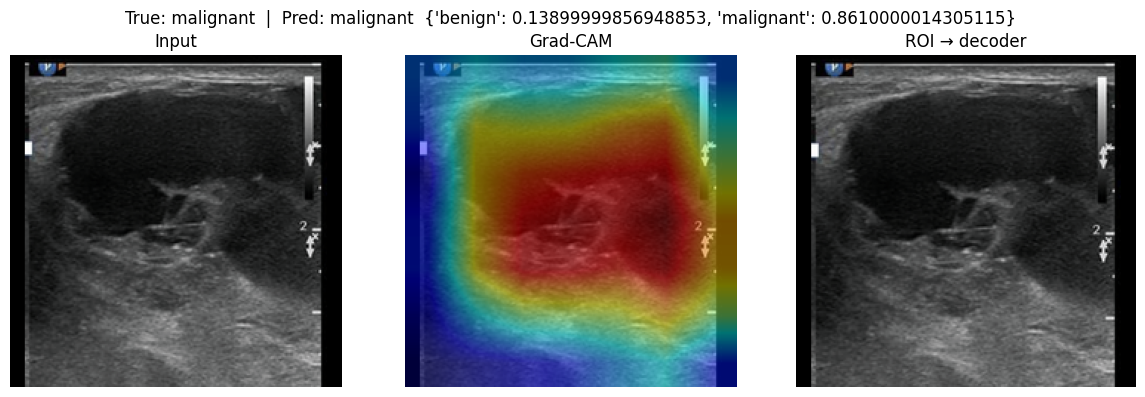

Generated caption: a breast ultrasound scan showing a malignant lesion with an occd in the upper part of the abdomen
BUS-CoT ground truth: This lesion is parallel, has circumscribed margins and round shape, This lesion has hypoechoicwith absence of calcific deposits. Based on these features, the lesion is classified as BIRADS 4A. The features are consistent with histopathology category: Postradiation angiosarcoma of the breast. Thus this is a malignant lesion.
----------------------------------------------------------------------------------------------------
Metrics -> ROUGE-1: 0.246 | ROUGE-L: 0.123 | Keyword Overlap: 16.2%


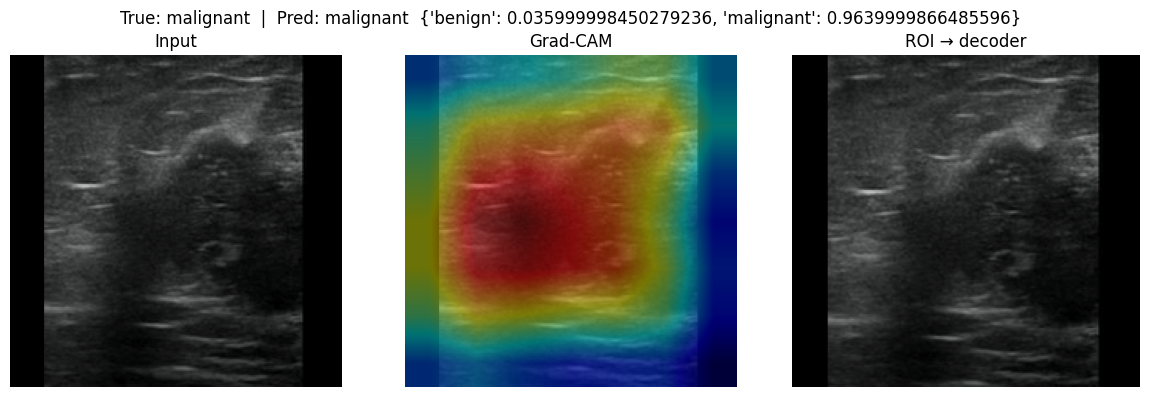

Generated caption: a breast ultrasound scan showing a malignant lesion with an abnormal bone fracture in the left side of the abdomen
BUS-CoT ground truth: This lesion is not parallel, has indistinct margins and irregular shape, This lesion has hypoechoicwith punctuate microcalcifications. Based on these features, the lesion is classified as BIRADS 4C. The features are consistent with histopathology category: None. Thus this is a malignant lesion.
----------------------------------------------------------------------------------------------------
Metrics -> ROUGE-1: 0.194 | ROUGE-L: 0.097 | Keyword Overlap: 14.7%


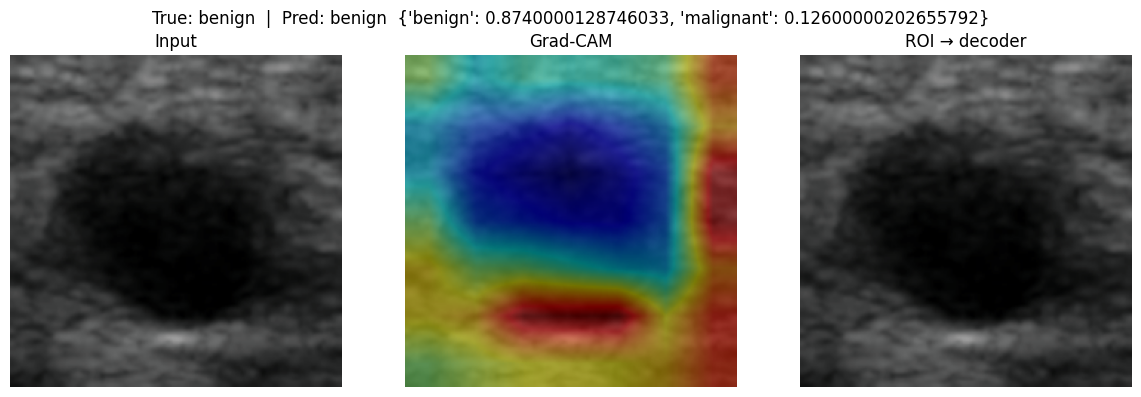

Generated caption: a breast ultrasound scan showing a benign lesion with a black hole in the middle of the abdomen, and a white spot at the end of
BUS-CoT ground truth: This lesion is not parallel, has angular margins and round shape, This lesion has hypoechoicwith absence of calcific deposits. Based on these features, the lesion is classified as BIRADS 3. The features are consistent with histopathology category: cyst. Thus this is a benign lesion.
----------------------------------------------------------------------------------------------------
Metrics -> ROUGE-1: 0.229 | ROUGE-L: 0.114 | Keyword Overlap: 19.4%


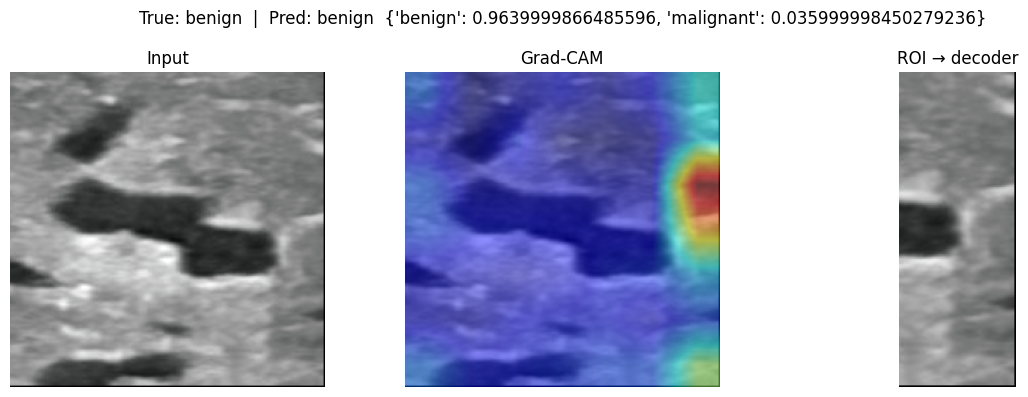

Generated caption: a breast ultrasound scan showing a benign lesion with a large lump on the right side of the abdomen
BUS-CoT ground truth: This lesion is parallel, has angular margins and round shape, This lesion has anechoicwith absence of calcific deposits. Based on these features, the lesion is classified as BIRADS 2. The features are consistent with histopathology category: None. Thus this is a benign lesion.
----------------------------------------------------------------------------------------------------
Metrics -> ROUGE-1: 0.258 | ROUGE-L: 0.129 | Keyword Overlap: 20.0%


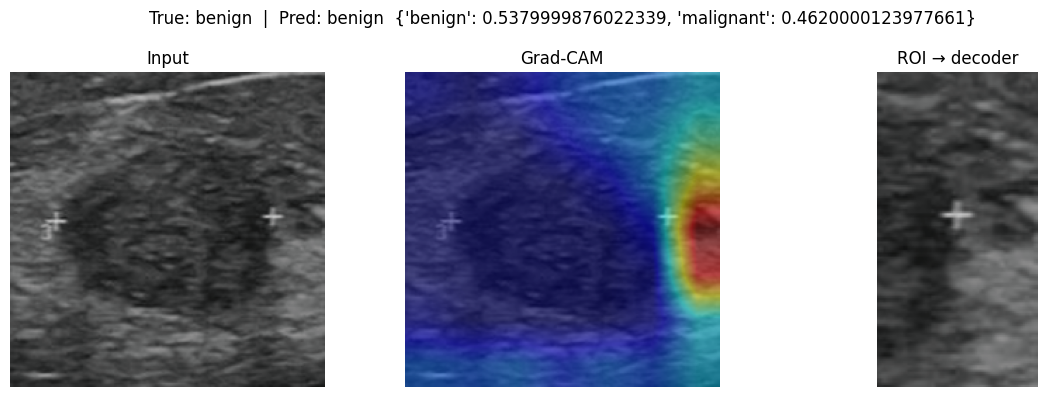

Generated caption: a breast ultrasound scan showing a benign lesion with an eject on the left side of the image
BUS-CoT ground truth: This lesion is parallel, has circumscribed margins and oval shape, This lesion has slightly hypoechoicwith absence of calcific deposits. Based on these features, the lesion is classified as BIRADS 4A. The features are consistent with histopathology category: Fibroadenoma. Thus this is a benign lesion.
----------------------------------------------------------------------------------------------------
Metrics -> ROUGE-1: 0.258 | ROUGE-L: 0.129 | Keyword Overlap: 19.4%


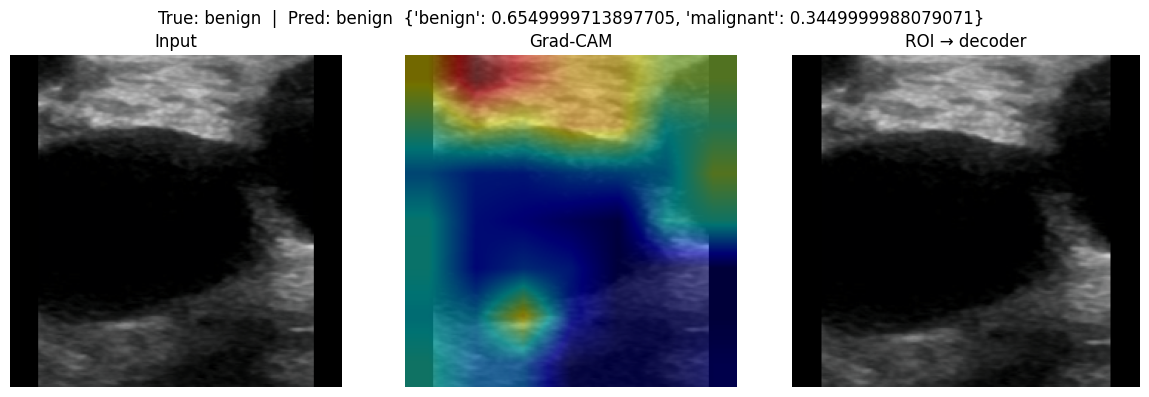

Generated caption: a breast ultrasound scan showing a benign lesion with a large lump at the end of the bone, and a small lump in the middle part
BUS-CoT ground truth: This lesion is not parallel, has circumscribed margins and oval shape, This lesion has anechoicwith absence of calcific deposits. Based on these features, the lesion is classified as BIRADS 3. The features are consistent with histopathology category: None. Thus this is a benign lesion.
----------------------------------------------------------------------------------------------------
Metrics -> ROUGE-1: 0.229 | ROUGE-L: 0.114 | Keyword Overlap: 19.4%

=== Evaluation Summary (Sample) ===
Mean ROUGE-1: 0.235
Mean ROUGE-L: 0.118
Mean Keyword Overlap: 18.2%


In [40]:
from rouge_score import rouge_scorer
import numpy as np

model.eval()

# Initialize the promised ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

rouge1_scores = []
rougeL_scores = []
keyword_overlaps = []

sample_rows = test_df.sample(n=min(6, len(test_df)), random_state=SEED)

for _, row in sample_rows.iterrows():
    res = explain_image(row["path"], true_label=row["label"], reasoning_gt=row["reasoning"])
    show_result(res)
    
    # 1. ROUGE Evaluation
    gt_text = res["reasoning_gt"]
    pred_text = res["caption"]
    scores = scorer.score(gt_text, pred_text)
    
    r1 = scores['rouge1'].fmeasure
    rl = scores['rougeL'].fmeasure
    rouge1_scores.append(r1)
    rougeL_scores.append(rl)
    
    # 2. Simple Keyword Overlap
    gt_words = set(gt_text.lower().split())
    pred_words = set(pred_text.lower().split())
    overlap = len(gt_words.intersection(pred_words)) / max(1, len(gt_words))
    keyword_overlaps.append(overlap)
    
    print(f"Metrics -> ROUGE-1: {r1:.3f} | ROUGE-L: {rl:.3f} | Keyword Overlap: {overlap:.1%}")
    print("=" * 100)

print("\n=== Evaluation Summary (Sample) ===")
print(f"Mean ROUGE-1: {np.mean(rouge1_scores):.3f}")
print(f"Mean ROUGE-L: {np.mean(rougeL_scores):.3f}")
print(f"Mean Keyword Overlap: {np.mean(keyword_overlaps):.1%}")
# Note: As stated in the intro, both are surface-overlap metrics, not faithfulness metrics.

## 13. Evaluate generated captions against BUS-CoT's own reasoning text

ROUGE-1/ROUGE-L for n-gram overlap, plus a cheap keyword-overlap score (fraction of non-trivial reference words that also appear in the generated caption) as a rough, dependency-free proxy for content coverage. **Neither of these is a faithfulness metric** &mdash; a caption can score well by being fluent and topically on-target while still getting the specific finding wrong. Treat this as a first-pass sanity check, not the final word on quality (see the note at the end).

In [41]:
import re
import pandas as pd
import numpy as np
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

# Words to ignore when scoring keyword overlap
STOPWORDS = set(
    "a an the is are was were of in on at to for with and or this that it its "
    "showing image images breast ultrasound scan shows appears seen".split()
)

def keyword_overlap(reference, hypothesis):
    def toks(s):
        # Extract lowercased words longer than 2 letters that aren't stopwords
        return {w for w in re.findall(r"[a-z]+", s.lower()) if w not in STOPWORDS and len(w) > 2}
    
    ref_toks, hyp_toks = toks(reference), toks(hypothesis)
    if not ref_toks:
        return float("nan")
    # Percentage of important ground-truth keywords present in the generated text
    return len(ref_toks & hyp_toks) / len(ref_toks)

eval_rows = []
# Sample up to 40 images from the test set to save processing time
eval_sample = test_df.sample(n=min(40, len(test_df)), random_state=SEED)

for _, row in eval_sample.iterrows():
    # 1. Run model prediction and generate text
    res = explain_image(row["path"], true_label=row["label"], reasoning_gt=row["reasoning"])
    
    # 2. Compute ROUGE similarity between ground-truth and generated text
    rouge = scorer.score(res["reasoning_gt"], res["caption"])
    
    eval_rows.append({
        "image_path": row["path"],  # Fixed: replaced "id" with "path"
        "true_label": res["true_label"],
        "pred_class": res["pred_class"],
        "correct": res["true_label"] == res["pred_class"],
        "rouge1_f": rouge["rouge1"].fmeasure,
        "rougeL_f": rouge["rougeL"].fmeasure,
        "keyword_overlap": keyword_overlap(res["reasoning_gt"], res["caption"]),
    })

eval_df = pd.DataFrame(eval_rows)

# Output evaluation metrics
print(eval_df[["rouge1_f", "rougeL_f", "keyword_overlap"]].describe())
print(f"\nClassifier accuracy on this eval subset: {eval_df['correct'].mean():.3f}")
print(f"Mean ROUGE-L: {eval_df['rougeL_f'].mean():.3f}  |  Mean keyword overlap: {eval_df['keyword_overlap'].mean():.3f}")

# Check if correct classifications produce better reasoning captions
print("\nMean rougeL_f, split by whether the classifier's prediction was correct:")
print(eval_df.groupby("correct")["rougeL_f"].mean())

        rouge1_f   rougeL_f  keyword_overlap
count  40.000000  40.000000        40.000000
mean    0.228900   0.118824         0.074867
std     0.025753   0.015723         0.023678
min     0.179104   0.093750         0.040000
25%     0.215533   0.110731         0.044960
50%     0.231884   0.118525         0.086957
75%     0.250992   0.129032         0.090909
max     0.264706   0.147059         0.136364

Classifier accuracy on this eval subset: 0.675
Mean ROUGE-L: 0.119  |  Mean keyword overlap: 0.075

Mean rougeL_f, split by whether the classifier's prediction was correct:
correct
False    0.117581
True     0.119422
Name: rougeL_f, dtype: float64


In [42]:
# A few worst- and best-scoring examples, for qualitative reading rather than just the averages
worst = eval_df.nsmallest(3, "rougeL_f")
best = eval_df.nlargest(3, "rougeL_f")

print("=== Lowest ROUGE-L (inspect these first) ===")
print(worst[["image_path", "true_label", "pred_class", "rougeL_f", "keyword_overlap"]])

print("\n=== Highest ROUGE-L ===")
print(best[["image_path", "true_label", "pred_class", "rougeL_f", "keyword_overlap"]])

=== Lowest ROUGE-L (inspect these first) ===
                                           image_path true_label pred_class  \
9   /kaggle/input/datasets/sabast/bus-cot/bus_cot/...     benign  malignant   
25  /kaggle/input/datasets/sabast/bus-cot/bus_cot/...     benign  malignant   
23  /kaggle/input/datasets/sabast/bus-cot/bus_cot/...     benign  malignant   

    rougeL_f  keyword_overlap  
9    0.09375         0.043478  
25   0.09375         0.043478  
23   0.09375         0.040000  

=== Highest ROUGE-L ===
                                           image_path true_label pred_class  \
29  /kaggle/input/datasets/sabast/bus-cot/bus_cot/...  malignant  malignant   
35  /kaggle/input/datasets/sabast/bus-cot/bus_cot/...  malignant  malignant   
10  /kaggle/input/datasets/sabast/bus-cot/bus_cot/...     benign  malignant   

    rougeL_f  keyword_overlap  
29  0.147059         0.090909  
35  0.147059         0.086957  
10  0.144928         0.043478  


## Notes & limitations

- **This is one dataset, one split.** Report k-fold results, not a single run, before citing any accuracy or ROUGE number in the thesis.
- **ROUGE/keyword overlap measure surface similarity, not correctness.** A caption can reuse the right words in the wrong combination ("no irregular margin" vs. "irregular margin") and still score well &mdash; exactly the failure mode flagged in the saliency-verbalization literature discussed earlier. If you want a stronger check, the next step is an entity-level or claim-level comparison (in the spirit of RadFact/MAIRA-2): extract discrete findings from both the generated caption and the ground-truth CoT text and check agreement per finding, rather than scoring whole sentences against each other.
- **The classifier and the decoder were evaluated somewhat independently here** &mdash; the `correct` vs. `rougeL_f` breakdown in Section 14 is a first look at whether caption quality tracks classification correctness, but it's worth deliberately checking cases where the classifier is *wrong*: does the caption confidently describe the wrong finding (bad &mdash; it's not grounded, it's just fluent), or does it hedge appropriately?
- **Label field choice matters a lot.** If `LABEL_FIELD` in Section 5 is the fine-grained pathology type (many classes, some rare), expect lower accuracy than a coarser BI-RADS-derived or benign/malignant grouping &mdash; try both and compare, since it changes what the Grad-CAM heatmaps (and therefore the captions) are actually explaining.
- **Multi-view cases:** Section 6 only uses the first image per case; `image_index[id]` holds all of them if you want to ensemble predictions or Grad-CAMs across views later.